In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
import tensorflow as tf
from tensorflow.keras.models import Sequential
import joblib

In [97]:
df = pd.read_csv("C:\\Users\\manan\\PropFTX AI2\\Prediction\\Bangalore\\Bangalore Property Data.csv")

In [98]:
print("size of df : " , df.shape)
print("df type of each colum in the df : ",df.dtypes)
print("no of null values :", df.isnull().sum())
duplicate_values = df.duplicated().sum()
print("no of duplicated values",duplicate_values)
numerical_summary = df.describe().T
print("Summary statistics for numerical columns:")
print(numerical_summary)

# Add mode and quartiles
mode = df.mode().iloc[0]  # Mode of each column
numerical_summary['Mode'] = mode
print("Updated summary statistics with mode:")
print(numerical_summary)


size of df :  (6638, 8)
df type of each colum in the df :  Locality         object
Quarter          object
Price Range      object
Average Price    object
Q-o-Q            object
Growth Type      object
City             object
Type             object
dtype: object
no of null values : Locality            0
Quarter             0
Price Range         7
Average Price       0
Q-o-Q             430
Growth Type      6587
City                3
Type                3
dtype: int64
no of duplicated values 10
Summary statistics for numerical columns:
              count unique                                   top  freq
Locality       6638    320                            Whitefield    40
Quarter        6638     27                          Jul-Sep 2024   322
Price Range    6631   6240                                     -   257
Average Price  6638   3910                                 6,000    31
Q-o-Q          6208    156                                    2%   944
Growth Type      51      3     

In [99]:
df.describe()

,Locality,Quarter,Price Range,Average Price,Q-o-Q,Growth Type,City,Type
count,6638,6638,6631,6638,6208,51,6635,6635
unique,320,27,6240,3910,156,3,1,2
top,Whitefield,Jul-Sep 2024,-,"6,000",2%,-,Bangalore,Residential - Multi Storey Apartment
freq,40,322,257,31,944,26,6635,6634


In [100]:
# df.drop(columns=['City','Type'])
df

,Locality,Quarter,Price Range,Average Price,Q-o-Q,Growth Type,City,Type
0,100 Feet Ring Road,Jul-Sep 2024,"7,264-13,013","10,139",0.40%,NaN,Bangalore,Residential - Multi Storey Apartment
1,100 Feet Ring Road,Apr-Jun 2024,"7,174-13,026","10,100",0.51%,-,Bangalore,Residential - Multi Storey Apartment
2,100 Feet Ring Road,Jan-Mar 2024,"7,100-13,000","10,050",NaN,-,Bangalore,Residential - Multi Storey Apartment
3,100 Feet Ring Road,Oct-Dec 2023,"7,050-12,950","10,005",NaN,-,Bangalore,Residential - Multi Storey Apartment
4,100 Feet Ring Road,Jul-Sep 2023,"7,000-12,900","9,970",NaN,-,Bangalore,Residential - Multi Storey Apartment
...,...,...,...,...,...,...,...,...
6633,Horamavu Agara,Jul-Sep 2019,"3,508-6,329","4,919",0.10%,NaN,Bangalore,Residential - Multi Storey Apartment
6634,Horamavu Agara,Apr-Jun 2019,"3,502-6,322","4,912",10%,NaN,Bangalore,Residential - Multi Storey Apartment
6635,Horamavu Agara,Jan-Mar 2019,"3,430-5,487","4,459",0.20%,NaN,Bangalore,Residential - Multi Storey Apartment
6636,Horamavu Agara,Oct-Dec 2018,"3,436-5,498","4,467",0.50%,NaN,Bangalore,Residential - Multi Storey Apartment


In [101]:
df.drop(columns=['Q-o-Q','Growth Type'], inplace= True)

In [102]:
df

,Locality,Quarter,Price Range,Average Price,City,Type
0,100 Feet Ring Road,Jul-Sep 2024,"7,264-13,013","10,139",Bangalore,Residential - Multi Storey Apartment
1,100 Feet Ring Road,Apr-Jun 2024,"7,174-13,026","10,100",Bangalore,Residential - Multi Storey Apartment
2,100 Feet Ring Road,Jan-Mar 2024,"7,100-13,000","10,050",Bangalore,Residential - Multi Storey Apartment
3,100 Feet Ring Road,Oct-Dec 2023,"7,050-12,950","10,005",Bangalore,Residential - Multi Storey Apartment
4,100 Feet Ring Road,Jul-Sep 2023,"7,000-12,900","9,970",Bangalore,Residential - Multi Storey Apartment
...,...,...,...,...,...,...
6633,Horamavu Agara,Jul-Sep 2019,"3,508-6,329","4,919",Bangalore,Residential - Multi Storey Apartment
6634,Horamavu Agara,Apr-Jun 2019,"3,502-6,322","4,912",Bangalore,Residential - Multi Storey Apartment
6635,Horamavu Agara,Jan-Mar 2019,"3,430-5,487","4,459",Bangalore,Residential - Multi Storey Apartment
6636,Horamavu Agara,Oct-Dec 2018,"3,436-5,498","4,467",Bangalore,Residential - Multi Storey Apartment


In [103]:
df['Month'] = df['Quarter'].str.split(' ', expand=True)[0] 
df['Year'] = df['Quarter'].str.split(' ', expand=True)[1]   

In [104]:
df.drop(columns=['Quarter'])

,Locality,Price Range,Average Price,City,Type,Month,Year
0,100 Feet Ring Road,"7,264-13,013","10,139",Bangalore,Residential - Multi Storey Apartment,Jul-Sep,2024
1,100 Feet Ring Road,"7,174-13,026","10,100",Bangalore,Residential - Multi Storey Apartment,Apr-Jun,2024
2,100 Feet Ring Road,"7,100-13,000","10,050",Bangalore,Residential - Multi Storey Apartment,Jan-Mar,2024
3,100 Feet Ring Road,"7,050-12,950","10,005",Bangalore,Residential - Multi Storey Apartment,Oct-Dec,2023
4,100 Feet Ring Road,"7,000-12,900","9,970",Bangalore,Residential - Multi Storey Apartment,Jul-Sep,2023
...,...,...,...,...,...,...,...
6633,Horamavu Agara,"3,508-6,329","4,919",Bangalore,Residential - Multi Storey Apartment,Jul-Sep,2019
6634,Horamavu Agara,"3,502-6,322","4,912",Bangalore,Residential - Multi Storey Apartment,Apr-Jun,2019
6635,Horamavu Agara,"3,430-5,487","4,459",Bangalore,Residential - Multi Storey Apartment,Jan-Mar,2019
6636,Horamavu Agara,"3,436-5,498","4,467",Bangalore,Residential - Multi Storey Apartment,Oct-Dec,2018


In [105]:
df.drop(columns=['Quarter'],inplace=True)

In [106]:
df

,Locality,Price Range,Average Price,City,Type,Month,Year
0,100 Feet Ring Road,"7,264-13,013","10,139",Bangalore,Residential - Multi Storey Apartment,Jul-Sep,2024
1,100 Feet Ring Road,"7,174-13,026","10,100",Bangalore,Residential - Multi Storey Apartment,Apr-Jun,2024
2,100 Feet Ring Road,"7,100-13,000","10,050",Bangalore,Residential - Multi Storey Apartment,Jan-Mar,2024
3,100 Feet Ring Road,"7,050-12,950","10,005",Bangalore,Residential - Multi Storey Apartment,Oct-Dec,2023
4,100 Feet Ring Road,"7,000-12,900","9,970",Bangalore,Residential - Multi Storey Apartment,Jul-Sep,2023
...,...,...,...,...,...,...,...
6633,Horamavu Agara,"3,508-6,329","4,919",Bangalore,Residential - Multi Storey Apartment,Jul-Sep,2019
6634,Horamavu Agara,"3,502-6,322","4,912",Bangalore,Residential - Multi Storey Apartment,Apr-Jun,2019
6635,Horamavu Agara,"3,430-5,487","4,459",Bangalore,Residential - Multi Storey Apartment,Jan-Mar,2019
6636,Horamavu Agara,"3,436-5,498","4,467",Bangalore,Residential - Multi Storey Apartment,Oct-Dec,2018


In [107]:
# from sklearn.preprocessing import LabelEncoder
# location_encoder = LabelEncoder()
# df['Locality'] = location_encoder.fit_transform(df['Locality'])
# print(df.head)
# joblib.dump(location_encoder,'location_encoding_test.pkl')

In [108]:
import numpy as np
df['Average Price'] = df['Average Price'].replace('-', np.nan)
df['Average Price'] = df['Average Price'].str.replace(',', '').astype(float)

In [109]:
df['Price Range'] = df['Price Range'].replace('-', '0-0').fillna('0-0')
df['Min Price'] = df['Price Range'].str.split('-').str[0].str.replace(',', '').replace('', '0').astype(float)
df['Max Price'] = df['Price Range'].str.split('-').str[1].str.replace(',', '').replace('', '0').astype(float)


In [110]:
print(df.isnull().sum())
df = df.dropna(subset=['Average Price', 'Min Price', 'Max Price'])


Locality         0
Price Range      0
Average Price    5
City             3
Type             3
Month            0
Year             0
Min Price        0
Max Price        0
dtype: int64


C:\Users\manan\AppData\Local\Temp\ipykernel_7968\1517563059.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Month_Encoded'] = df['Month'].map({


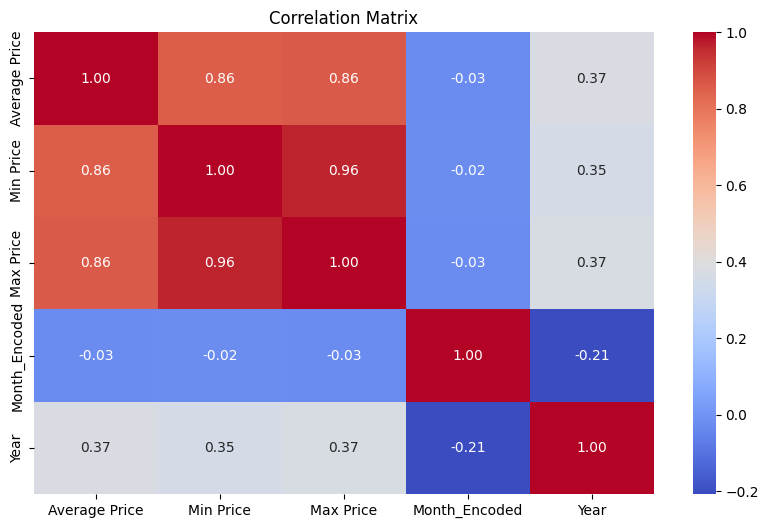

In [111]:
df['Month_Encoded'] = df['Month'].map({
    'Jan-Mar': 1,
    'Apr-Jun': 2,
    'Jul-Sep': 3,
    'Oct-Dec': 4
})
# df['City_Encoded'] = df['City'].factorize()[0]
# df['Type_Encoded'] = df['Type'].factorize()[0]

# Select numerical columns for correlation analysis
numerical_cols = ['Average Price', 'Min Price', 'Max Price', 'Month_Encoded', 'Year']

# Compute the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Visualize the correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [112]:
df.drop(columns=['Price Range','City','Type'],inplace=True)

C:\Users\manan\AppData\Local\Temp\ipykernel_7968\1663544092.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Price Range','City','Type'],inplace=True)


In [113]:
df

,Locality,Average Price,Month,Year,Min Price,Max Price,Month_Encoded
0,100 Feet Ring Road,10139.0,Jul-Sep,2024,7264.0,13013.0,3
1,100 Feet Ring Road,10100.0,Apr-Jun,2024,7174.0,13026.0,2
2,100 Feet Ring Road,10050.0,Jan-Mar,2024,7100.0,13000.0,1
3,100 Feet Ring Road,10005.0,Oct-Dec,2023,7050.0,12950.0,4
4,100 Feet Ring Road,9970.0,Jul-Sep,2023,7000.0,12900.0,3
...,...,...,...,...,...,...,...
6633,Horamavu Agara,4919.0,Jul-Sep,2019,3508.0,6329.0,3
6634,Horamavu Agara,4912.0,Apr-Jun,2019,3502.0,6322.0,2
6635,Horamavu Agara,4459.0,Jan-Mar,2019,3430.0,5487.0,1
6636,Horamavu Agara,4467.0,Oct-Dec,2018,3436.0,5498.0,4


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6633 entries, 0 to 6637
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Locality       6633 non-null   object 
 1   Average Price  6633 non-null   float64
 2   Month          6633 non-null   object 
 3   Year           6633 non-null   object 
 4   Min Price      6633 non-null   float64
 5   Max Price      6633 non-null   float64
 6   Month_Encoded  6633 non-null   int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 414.6+ KB


In [115]:
df['Year'] = df['Year'].astype('float64')


C:\Users\manan\AppData\Local\Temp\ipykernel_7968\2649418009.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Year'].astype('float64')


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6633 entries, 0 to 6637
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Locality       6633 non-null   object 
 1   Average Price  6633 non-null   float64
 2   Month          6633 non-null   object 
 3   Year           6633 non-null   float64
 4   Min Price      6633 non-null   float64
 5   Max Price      6633 non-null   float64
 6   Month_Encoded  6633 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 414.6+ KB


In [117]:
df

,Locality,Average Price,Month,Year,Min Price,Max Price,Month_Encoded
0,100 Feet Ring Road,10139.0,Jul-Sep,2024.0,7264.0,13013.0,3
1,100 Feet Ring Road,10100.0,Apr-Jun,2024.0,7174.0,13026.0,2
2,100 Feet Ring Road,10050.0,Jan-Mar,2024.0,7100.0,13000.0,1
3,100 Feet Ring Road,10005.0,Oct-Dec,2023.0,7050.0,12950.0,4
4,100 Feet Ring Road,9970.0,Jul-Sep,2023.0,7000.0,12900.0,3
...,...,...,...,...,...,...,...
6633,Horamavu Agara,4919.0,Jul-Sep,2019.0,3508.0,6329.0,3
6634,Horamavu Agara,4912.0,Apr-Jun,2019.0,3502.0,6322.0,2
6635,Horamavu Agara,4459.0,Jan-Mar,2019.0,3430.0,5487.0,1
6636,Horamavu Agara,4467.0,Oct-Dec,2018.0,3436.0,5498.0,4


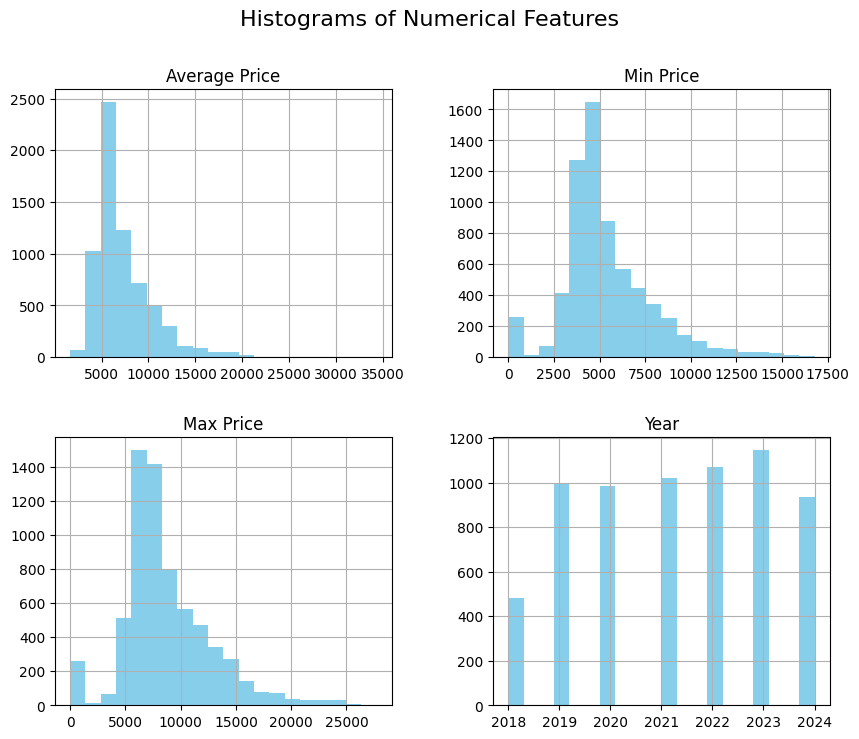

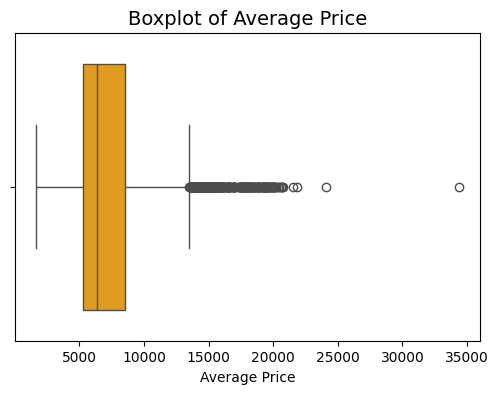

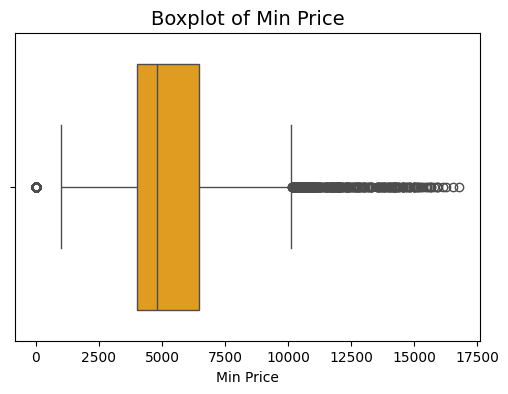

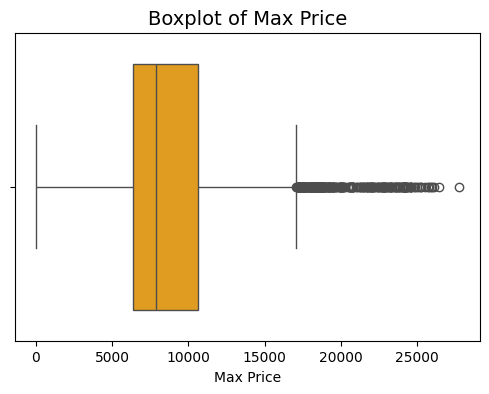

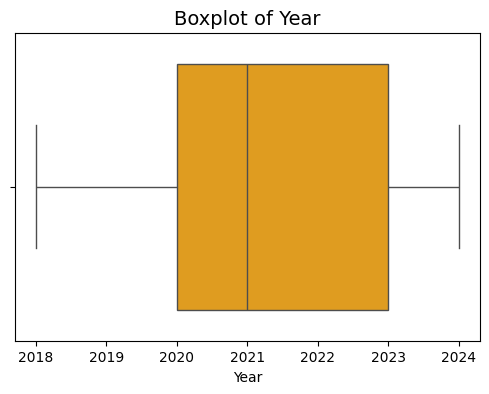

In [118]:
# Plot histograms for numerical columns
numerical_features = ['Average Price', 'Min Price', 'Max Price', 'Year']
df[numerical_features].hist(bins=20, figsize=(10, 8), color='skyblue')
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.show()

# Box plots for numerical columns
for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[feature], color='orange')
    plt.title(f'Boxplot of {feature}', fontsize=14)
    plt.show()


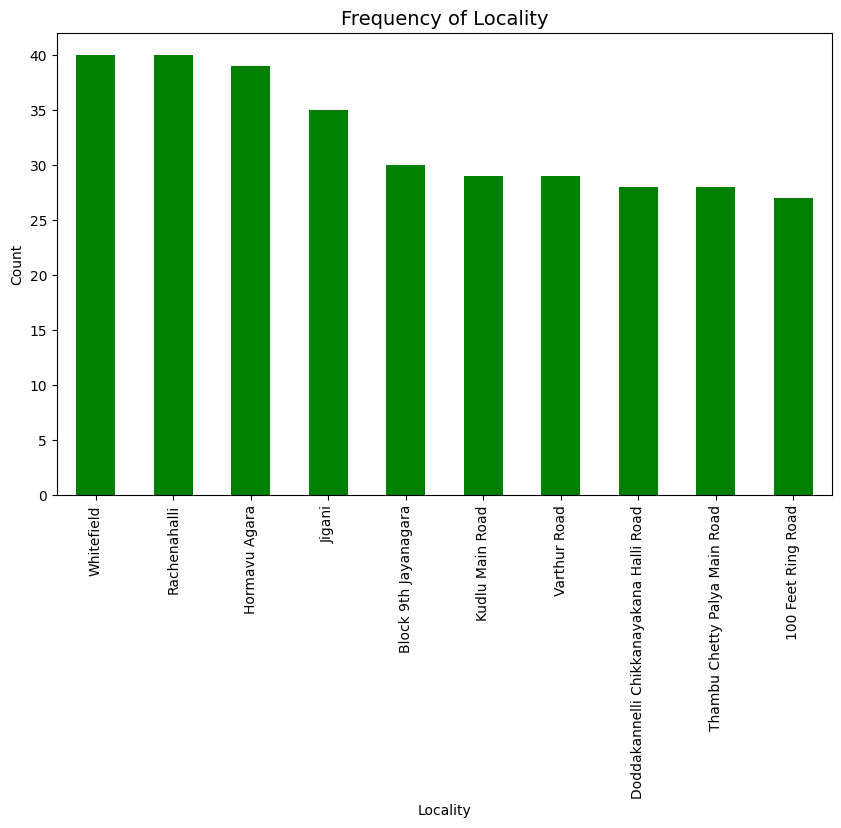

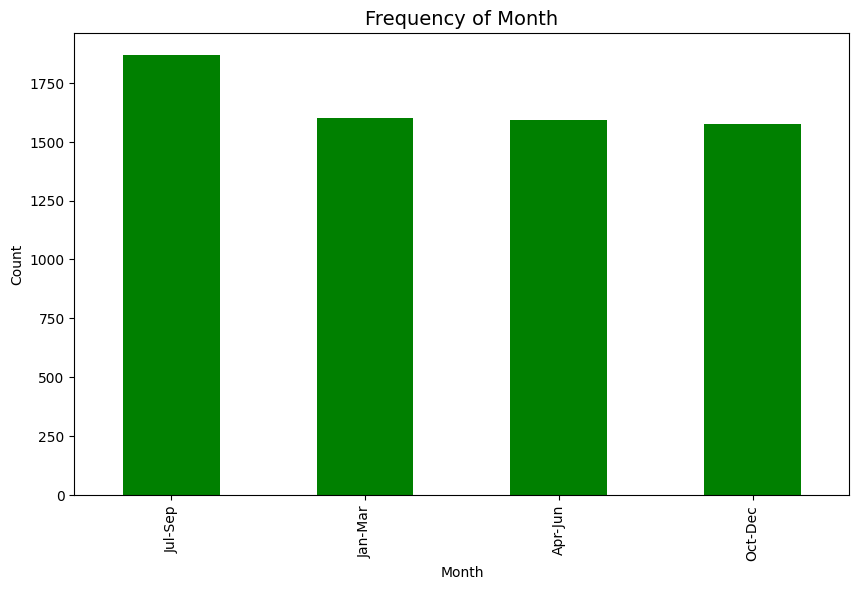

In [119]:
# Frequency tables and bar charts for categorical columns
categorical_features = ['Locality', 'Month']
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    df[feature].value_counts().head(10).plot(kind='bar', color='green')
    plt.title(f'Frequency of {feature}', fontsize=14)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()


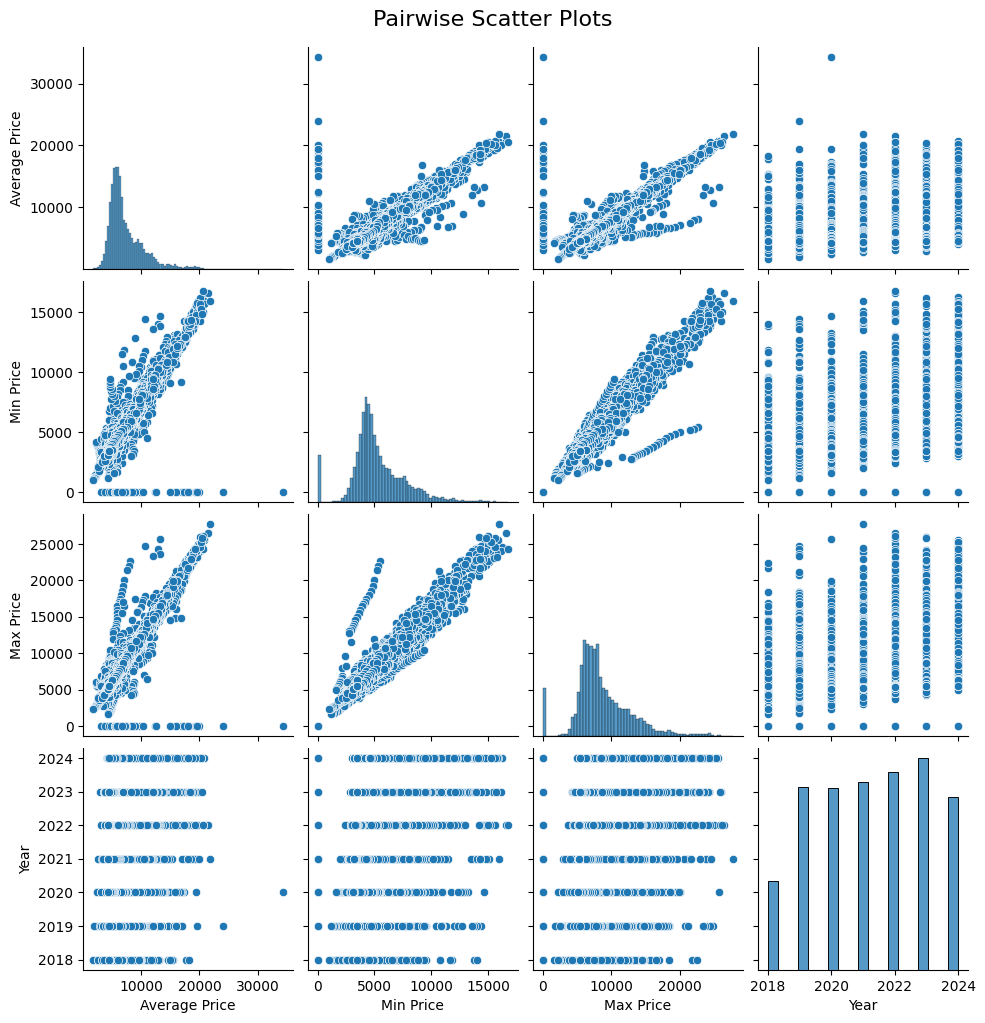

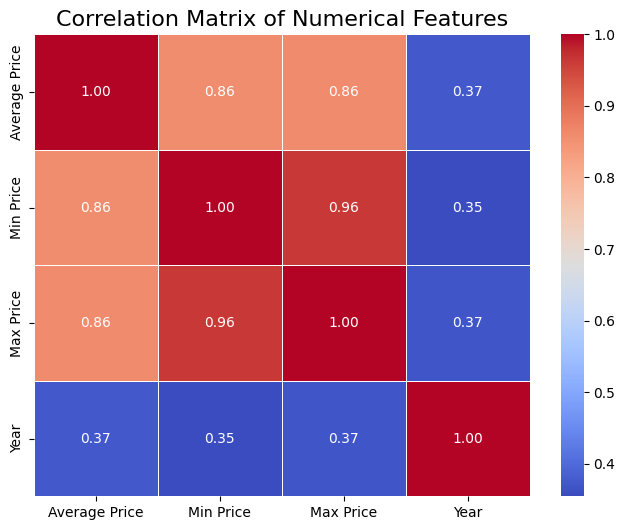

In [120]:
# Scatter plot to visualize relationships between numerical features
sns.pairplot(df[numerical_features])
plt.suptitle('Pairwise Scatter Plots', y=1.02, fontsize=16)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()


C:\Users\manan\AppData\Local\Temp\ipykernel_7968\1340889095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y=feature, data=df, palette='Set2')


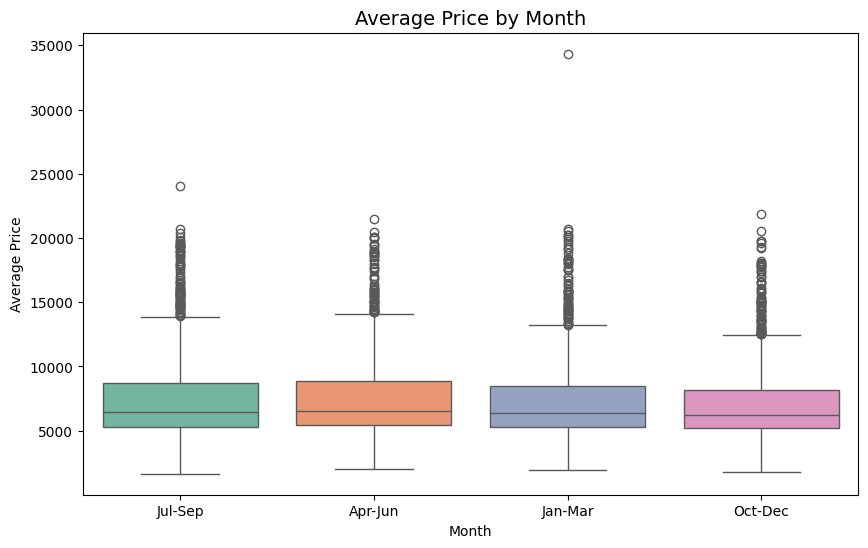

C:\Users\manan\AppData\Local\Temp\ipykernel_7968\1340889095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y=feature, data=df, palette='Set2')


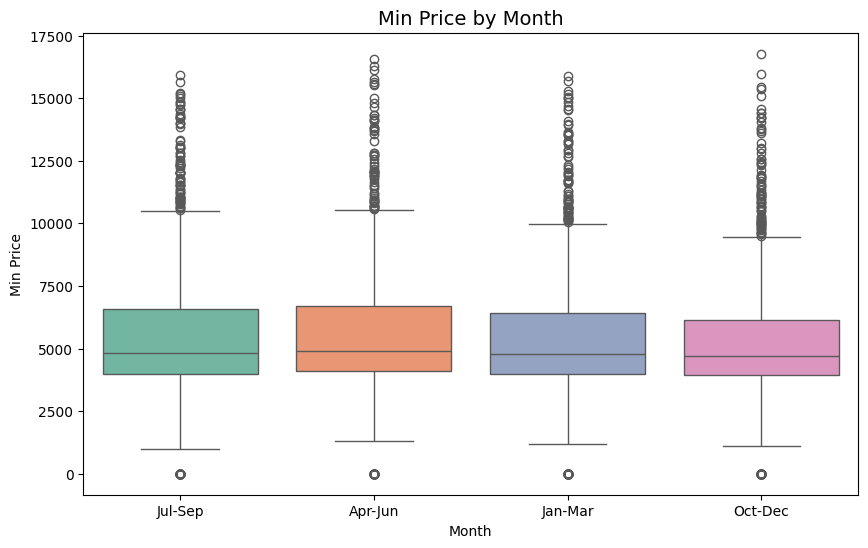

C:\Users\manan\AppData\Local\Temp\ipykernel_7968\1340889095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y=feature, data=df, palette='Set2')


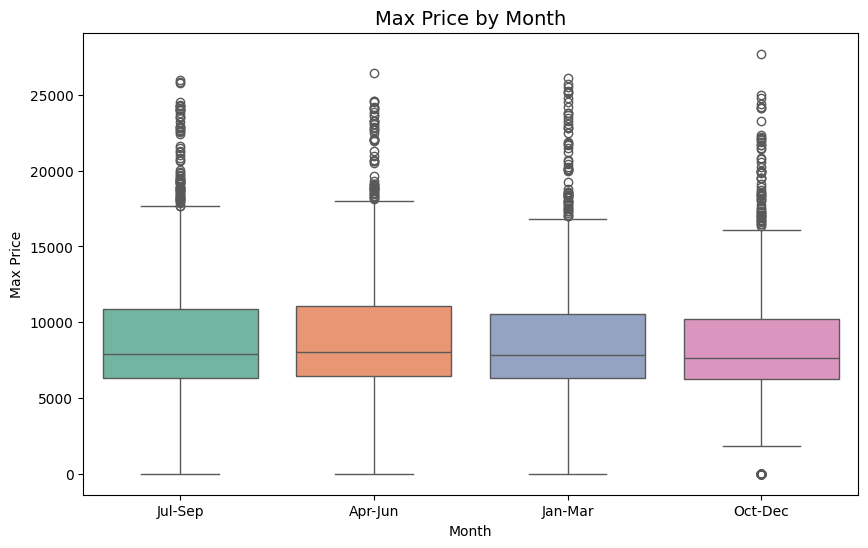

C:\Users\manan\AppData\Local\Temp\ipykernel_7968\1340889095.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y=feature, data=df, palette='Set2')


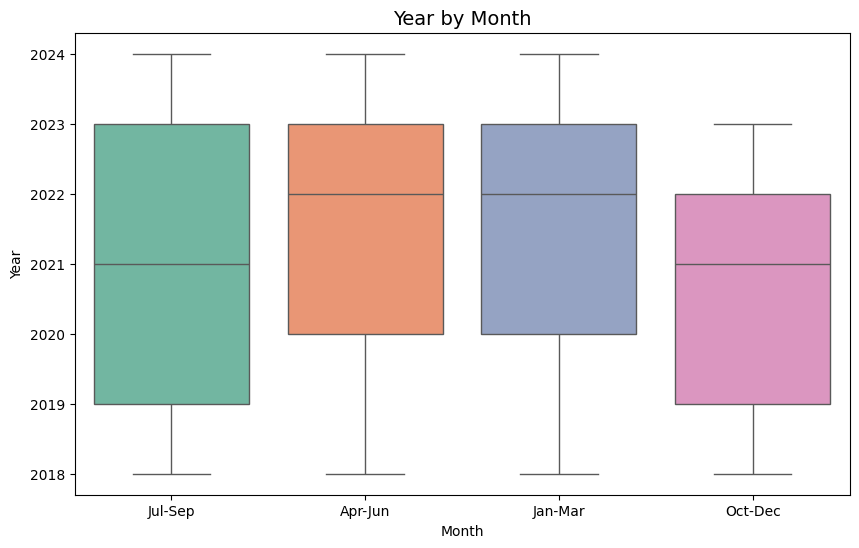

In [121]:
# Box plots to compare numerical features across categories
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Month', y=feature, data=df, palette='Set2')
    plt.title(f'{feature} by Month', fontsize=14)
    plt.xlabel('Month')
    plt.ylabel(feature)
    plt.show()


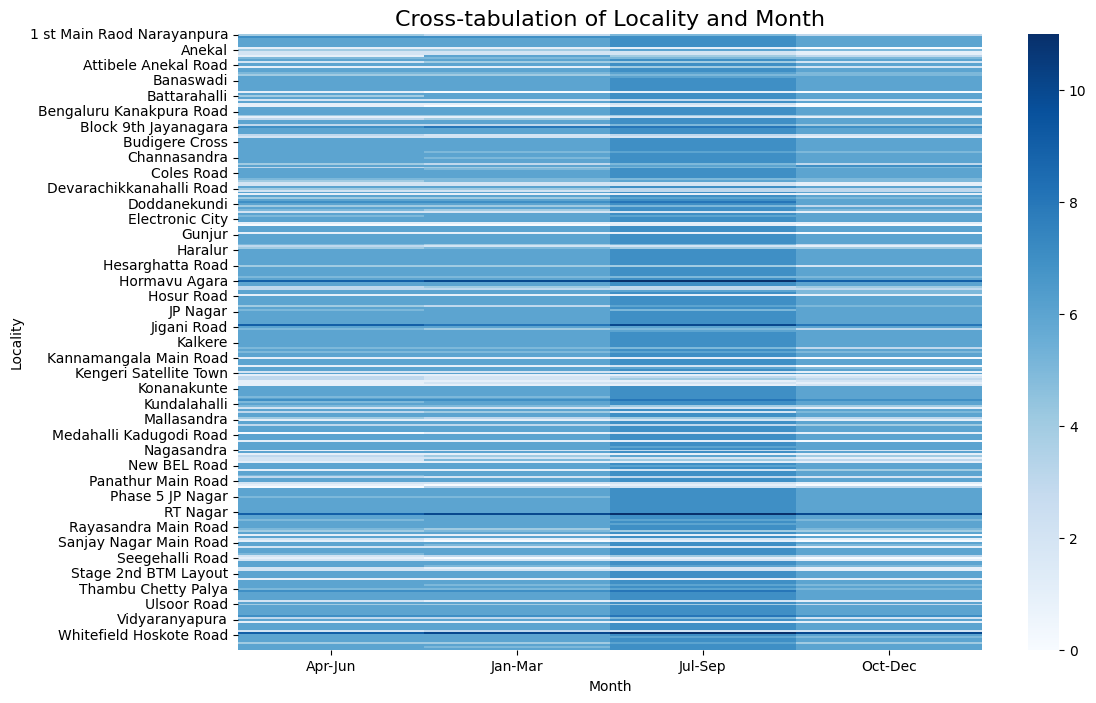

In [122]:
# Cross-tabulation and heatmap
cross_tab = pd.crosstab(df['Locality'], df['Month'])
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, cmap='Blues', annot=False, cbar=True)
plt.title('Cross-tabulation of Locality and Month', fontsize=16)
plt.show()


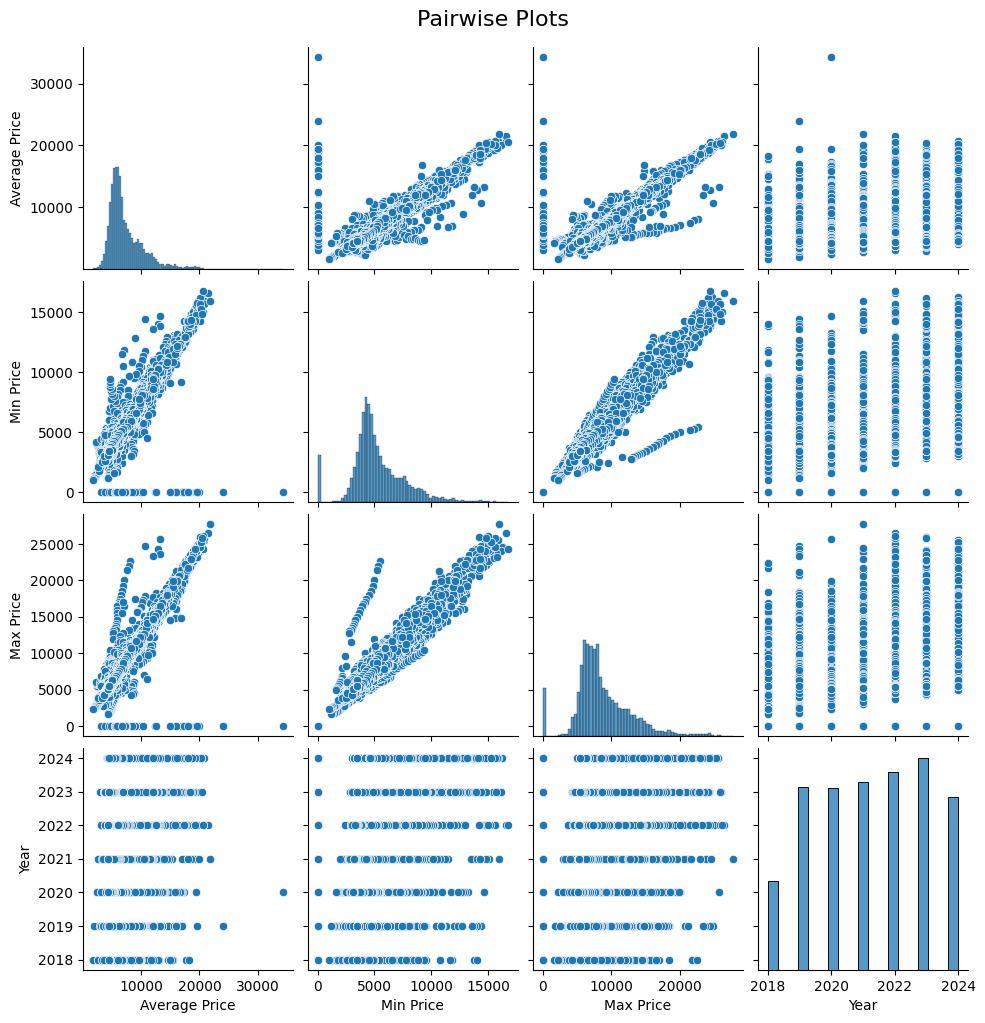

In [123]:
# Pair plot for selected features
selected_features = ['Average Price', 'Min Price', 'Max Price', 'Year']
sns.pairplot(df[selected_features])
plt.suptitle('Pairwise Plots', y=1.02, fontsize=16)
plt.show()


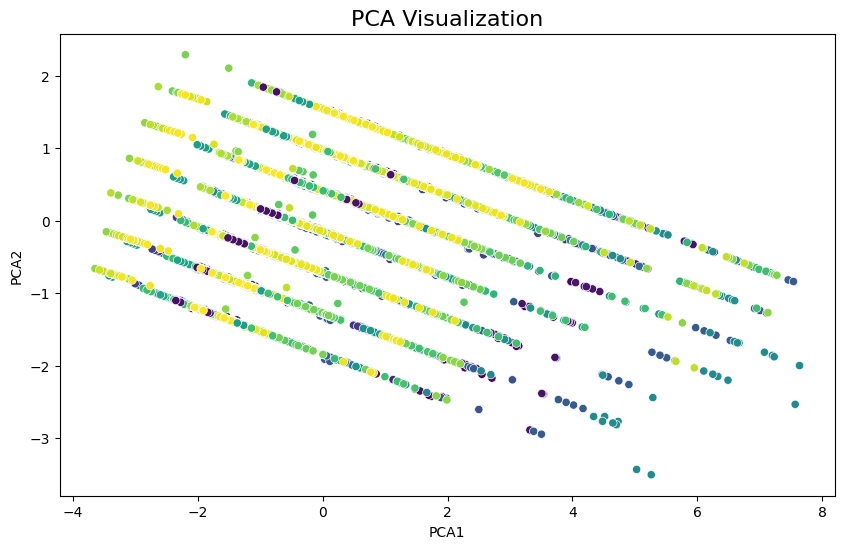

In [124]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_scaled = scaler.fit_transform(df[numerical_features])

pca = PCA(n_components=2)
pca_result = pca.fit_transform(numerical_scaled)

pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
pca_df['Locality'] = df['Locality']

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Locality', data=pca_df, legend=False, palette='viridis')
plt.title('PCA Visualization', fontsize=16)
plt.show()


In [125]:
df = df.drop(df[df['Month'] == 'April-June'].index)

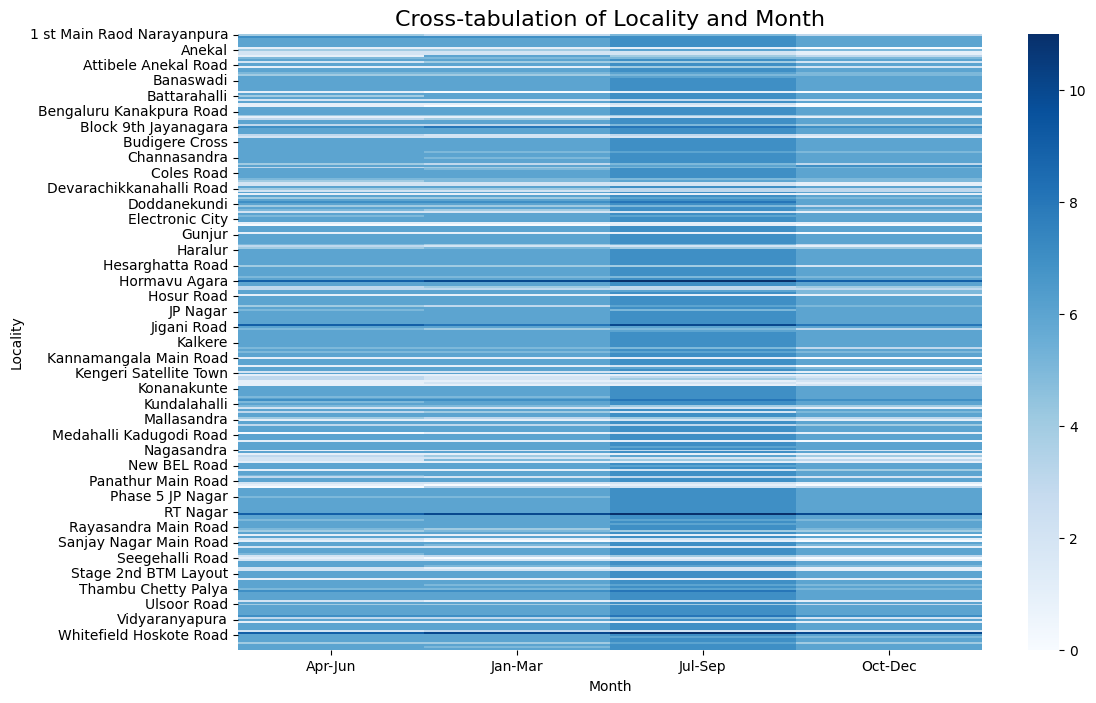

In [126]:
# Cross-tabulation and heatmap
cross_tab = pd.crosstab(df['Locality'], df['Month'])
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, cmap='Blues', annot=False, cbar=True)
plt.title('Cross-tabulation of Locality and Month', fontsize=16)
plt.show()

In [127]:
from sklearn.preprocessing import MinMaxScaler
columns_to_scale = ['Average Price', 'Min Price', 'Max Price']
scaler = MinMaxScaler(feature_range=(1, 10))
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
joblib.dump(scaler,'Bangalore_price_scaling.pkl')

['Bangalore_price_scaling.pkl']

In [128]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Locality'] = encoder.fit_transform(df['Locality'])
scaler = MinMaxScaler(feature_range=(1,10))
df[['Locality']] = scaler.fit_transform(df[['Locality']])
joblib.dump(encoder,'Bangalore_locality_encoding.pkl')
joblib.dump(scaler,'Bangalore_locality_scaling.pkl')


['Bangalore_locality_scaling.pkl']

In [129]:
df

,Locality,Average Price,Month,Year,Min Price,Max Price,Month_Encoded
0,1.028213,3.336422,Jul-Sep,2024.0,4.897228,5.224390,3
1,1.028213,3.325688,Apr-Jun,2024.0,4.848942,5.228611,2
2,1.028213,3.311927,Jan-Mar,2024.0,4.809240,5.220170,1
3,1.028213,3.299541,Oct-Dec,2023.0,4.782414,5.203939,4
4,1.028213,3.289908,Jul-Sep,2023.0,4.755589,5.187707,3
...,...,...,...,...,...,...,...
6633,4.526646,1.899725,Jul-Sep,2019.0,2.882086,3.054574,3
6634,4.526646,1.897798,Apr-Jun,2019.0,2.878867,3.052301,2
6635,4.526646,1.773119,Jan-Mar,2019.0,2.840238,2.781236,1
6636,4.526646,1.775321,Oct-Dec,2018.0,2.843458,2.784807,4


In [130]:
month_mapping = {
    "Jan-Mar": 1,
    "Apr-Jun": 2,
    "Jul-Sep": 3,
    "Oct-Dec": 4
}
df['Month_Mapped'] = df['Month'].map(month_mapping)

In [131]:
df

,Locality,Average Price,Month,Year,Min Price,Max Price,Month_Encoded,Month_Mapped
0,1.028213,3.336422,Jul-Sep,2024.0,4.897228,5.224390,3,3
1,1.028213,3.325688,Apr-Jun,2024.0,4.848942,5.228611,2,2
2,1.028213,3.311927,Jan-Mar,2024.0,4.809240,5.220170,1,1
3,1.028213,3.299541,Oct-Dec,2023.0,4.782414,5.203939,4,4
4,1.028213,3.289908,Jul-Sep,2023.0,4.755589,5.187707,3,3
...,...,...,...,...,...,...,...,...
6633,4.526646,1.899725,Jul-Sep,2019.0,2.882086,3.054574,3,3
6634,4.526646,1.897798,Apr-Jun,2019.0,2.878867,3.052301,2,2
6635,4.526646,1.773119,Jan-Mar,2019.0,2.840238,2.781236,1,1
6636,4.526646,1.775321,Oct-Dec,2018.0,2.843458,2.784807,4,4


In [132]:
df.drop(columns=['Month'])

,Locality,Average Price,Year,Min Price,Max Price,Month_Encoded,Month_Mapped
0,1.028213,3.336422,2024.0,4.897228,5.224390,3,3
1,1.028213,3.325688,2024.0,4.848942,5.228611,2,2
2,1.028213,3.311927,2024.0,4.809240,5.220170,1,1
3,1.028213,3.299541,2023.0,4.782414,5.203939,4,4
4,1.028213,3.289908,2023.0,4.755589,5.187707,3,3
...,...,...,...,...,...,...,...
6633,4.526646,1.899725,2019.0,2.882086,3.054574,3,3
6634,4.526646,1.897798,2019.0,2.878867,3.052301,2,2
6635,4.526646,1.773119,2019.0,2.840238,2.781236,1,1
6636,4.526646,1.775321,2018.0,2.843458,2.784807,4,4


In [133]:
df['Year_sin'] = np.sin(2 * np.pi * (df['Year'] - df['Year'].min()) / (df['Year'].max() - df['Year'].min()))
df['Year_cos'] = np.cos(2 * np.pi * (df['Year'] - df['Year'].min()) / (df['Year'].max() - df['Year'].min()))


In [134]:
df

,Locality,Average Price,Month,Year,Min Price,Max Price,Month_Encoded,Month_Mapped,Year_sin,Year_cos
0,1.028213,3.336422,Jul-Sep,2024.0,4.897228,5.224390,3,3,-2.449294e-16,1.0
1,1.028213,3.325688,Apr-Jun,2024.0,4.848942,5.228611,2,2,-2.449294e-16,1.0
2,1.028213,3.311927,Jan-Mar,2024.0,4.809240,5.220170,1,1,-2.449294e-16,1.0
3,1.028213,3.299541,Oct-Dec,2023.0,4.782414,5.203939,4,4,-8.660254e-01,0.5
4,1.028213,3.289908,Jul-Sep,2023.0,4.755589,5.187707,3,3,-8.660254e-01,0.5
...,...,...,...,...,...,...,...,...,...,...
6633,4.526646,1.899725,Jul-Sep,2019.0,2.882086,3.054574,3,3,8.660254e-01,0.5
6634,4.526646,1.897798,Apr-Jun,2019.0,2.878867,3.052301,2,2,8.660254e-01,0.5
6635,4.526646,1.773119,Jan-Mar,2019.0,2.840238,2.781236,1,1,8.660254e-01,0.5
6636,4.526646,1.775321,Oct-Dec,2018.0,2.843458,2.784807,4,4,0.000000e+00,1.0


In [135]:
df.drop(columns=['Year','Month','Month_Mapped'],inplace=True)

In [136]:
# df.drop(columns=['Month_Mapped'],inplace=True)

In [137]:
df

,Locality,Average Price,Min Price,Max Price,Month_Encoded,Year_sin,Year_cos
0,1.028213,3.336422,4.897228,5.224390,3,-2.449294e-16,1.0
1,1.028213,3.325688,4.848942,5.228611,2,-2.449294e-16,1.0
2,1.028213,3.311927,4.809240,5.220170,1,-2.449294e-16,1.0
3,1.028213,3.299541,4.782414,5.203939,4,-8.660254e-01,0.5
4,1.028213,3.289908,4.755589,5.187707,3,-8.660254e-01,0.5
...,...,...,...,...,...,...,...
6633,4.526646,1.899725,2.882086,3.054574,3,8.660254e-01,0.5
6634,4.526646,1.897798,2.878867,3.052301,2,8.660254e-01,0.5
6635,4.526646,1.773119,2.840238,2.781236,1,8.660254e-01,0.5
6636,4.526646,1.775321,2.843458,2.784807,4,0.000000e+00,1.0


In [138]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ['Locality', 'Month_Encoded', 'Year_sin', 'Year_cos']
target = 'Average Price'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Calculating MAPE
mape = (abs((y_test - y_pred) / y_test).mean()) * 100

print("Model Performance:") 
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

import joblib
joblib.dump(model, "Bangalore_Prediction_Model.pkl")


Model Performance:
Mean Absolute Error (MAE): 0.22363848899820013
Mean Squared Error (MSE): 0.13428603101946895
R² Score: 0.805689605703323
Mean Absolute Percentage Error (MAPE): 8.500782155498035%


['Bangalore_Prediction_Model.pkl']

In [139]:
import pandas as pd
import numpy as np
import joblib

encoder = joblib.load('C:\\Users\\manan\\PropFTX AI2\\Prediction\\Bangalore\\Bangalore_locality_encoding.pkl')
scaler = joblib.load('C:\\Users\\manan\\PropFTX AI2\\Prediction\\Bangalore\\Bangalore_locality_scaling.pkl')
price_scaler = joblib.load('C:\\Users\\manan\\PropFTX AI2\\Prediction\\Bangalore\\Bangalore_price_scaling.pkl')
month_mapping = {
    'Jan-Mar': 1,
    'Apr-Jun': 2,
    'Jul-Sep': 3,
    'Oct-Dec': 4
}

def compute_year_sin_cos(year):
    base_year = 2019
    period = 6  
    year_index = year - base_year
    year_sin = np.sin(2 * np.pi * year_index / period)
    year_cos = np.cos(2 * np.pi * year_index / period)
    return year_sin, year_cos
def predict_price(location, year, quarter):
    location_encoded = encoder.transform([location])[0]
    location_scaled = scaler.transform([[location_encoded]])[0][0]  # Scaling after encoding

    month_encoded = month_mapping.get(quarter, None)
    if month_encoded is None:
        raise ValueError("Invalid quarter provided. Must be 'Jan-Mar', 'Apr-Jun', 'Jul-Sep', or 'Oct-Dec'.")

    year_sin, year_cos = compute_year_sin_cos(year)

    input_data = pd.DataFrame([[location_scaled, month_encoded, year_sin, year_cos]],
                              columns=['Locality', 'Month_Encoded', 'Year_sin', 'Year_cos'])

    model = joblib.load("C:\\Users\\manan\\PropFTX AI2\\Prediction\\Bangalore\\Bangalore_Prediction_Model.pkl")

    predicted_price_scaled = model.predict(input_data)[0]

    temp_data = [[predicted_price_scaled, None, None]]  
    predicted_price = price_scaler.inverse_transform(temp_data)[0][0]

    return predicted_price

location = 'JP Nagar'
year = 2030
quarter = 'Oct-Dec'

predicted_price = predict_price(location, year, quarter)
print(f"Predicted Average Price for {location} in {quarter} {year}: ₹{predicted_price}")


Predicted Average Price for JP Nagar in Oct-Dec 2030: ₹8125.380000000002


c:\Users\manan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [140]:
import pandas as pd
import numpy as np
import joblib

encoder = joblib.load('C:\\Users\\manan\\PropFTX AI2\\Prediction\\Bangalore\Bangalore_locality_encoding.pkl')
scaler = joblib.load('C:\\Users\\manan\\PropFTX AI2\\Prediction\\Bangalore\\Bangalore_locality_scaling.pkl')
price_scaler = joblib.load('C:\\Users\\manan\\PropFTX AI2\\Prediction\\Bangalore\\Bangalore_price_scaling.pkl')
month_mapping = {
    'Jan-Mar': 1,
    'Apr-Jun': 2,
    'Jul-Sep': 3,
    'Oct-Dec': 4
}

def compute_year_sin_cos(year):
    base_year = 2019
    period = 6  
    year_index = year - base_year
    year_sin = np.sin(2 * np.pi * year_index / period)
    year_cos = np.cos(2 * np.pi * year_index / period)
    return year_sin, year_cos

def predict_price(location, year, quarter, historical_data):
    # Encode and scale locality
    location_encoded = encoder.transform([location])[0]
    location_scaled = scaler.transform([[location_encoded]])[0][0]  # Scaling after encoding

    month_encoded = month_mapping.get(quarter, None)
    if month_encoded is None:
        raise ValueError("Invalid quarter provided. Must be 'Jan-Mar', 'Apr-Jun', 'Jul-Sep', or 'Oct-Dec'.")

    year_sin, year_cos = compute_year_sin_cos(year)

    input_data = pd.DataFrame([[location_scaled, month_encoded, year_sin, year_cos]],
                              columns=['Locality', 'Month_Encoded', 'Year_sin', 'Year_cos'])

    model = joblib.load("C:\\Users\\manan\\PropFTX AI2\\Prediction\\Bangalore\\Bangalore_Prediction_Model.pkl")

    predicted_price_scaled = model.predict(input_data)[0]

    temp_data = [[predicted_price_scaled, None, None]]  
    predicted_price = price_scaler.inverse_transform(temp_data)[0][0]

    locality_data = historical_data[historical_data['Locality'] == location]
    if locality_data.empty:
        raise ValueError(f"No historical data available for {location}.")
 
    locality_data['Price Range'] = locality_data['Price Range'].str.replace(',', '', regex=False)
    locality_data[['Min Price', 'Max Price']] = locality_data['Price Range'].str.split('-', expand=True).astype(float)
    locality_data['Average Price'] = locality_data['Average Price'].str.replace(',', '', regex=False).astype(float)

    min_price_factor = locality_data['Min Price'].mean() / locality_data['Average Price'].mean()
    max_price_factor = locality_data['Max Price'].mean() / locality_data['Average Price'].mean()

    predicted_min_price = predicted_price * min_price_factor
    predicted_max_price = predicted_price * max_price_factor

    return predicted_price, predicted_min_price, predicted_max_price


location=  'Jayanagar'
year = 2024
quarter = 'Jan-Mar'

historical_data = pd.read_csv("C:\\Users\\manan\\PropFTX AI2\\Prediction\\Bangalore\\Bangalore Property Data.csv")

predicted_price, predicted_min_price, predicted_max_price = predict_price(location, year, quarter, historical_data)

print(f"Predicted Average Price for {location} in {quarter} {year}: ₹{predicted_price:,.2f}")
print(f"Predicted Minimum Price for {location} in {quarter} {year}: ₹{predicted_min_price:,.2f}")
print(f"Predicted Maximum Price for {location} in {quarter} {year}: ₹{predicted_max_price:,.2f}")

Predicted Average Price for Jayanagar in Jan-Mar 2024: ₹11,306.42
Predicted Minimum Price for Jayanagar in Jan-Mar 2024: ₹9,088.15
Predicted Maximum Price for Jayanagar in Jan-Mar 2024: ₹14,022.75


<>:5: SyntaxWarning: invalid escape sequence '\B'
<>:5: SyntaxWarning: invalid escape sequence '\B'
C:\Users\manan\AppData\Local\Temp\ipykernel_7968\1410791882.py:5: SyntaxWarning: invalid escape sequence '\B'
  encoder = joblib.load('C:\\Users\\manan\\PropFTX AI2\\Prediction\\Bangalore\Bangalore_locality_encoding.pkl')
c:\Users\manan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\manan\AppData\Local\Temp\ipykernel_7968\1410791882.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locality_data['Price Range'] = locality_data['Price Range'].str.replace(',', '', regex=False)
C:\Users\manan\AppD